In [1]:
import os, subprocess

REPO_URL = "https://github.com/tongyuguo/HelpHerInvest.git"
REPO_DIR = "HelpHerInvest"
data_dir = os.path.join(REPO_DIR, "Data")

def clone_or_pull():
    if os.path.isdir(os.path.join(REPO_DIR, ".git")):
        subprocess.run(["git", "-C", REPO_DIR, "pull"])
    else:
        subprocess.run(["git", "clone", REPO_URL])

clone_or_pull()

Updating 6c1a3bc..eae5f64
Fast-forward
 Data/stock_symbols_new.csv                         |    4 -
 .../Tongyu Playground/nlp data cleaning.ipynb      | 2765 ++++++++++++++++++++
 2 files changed, 2765 insertions(+), 4 deletions(-)
 delete mode 100644 Data/stock_symbols_new.csv
 create mode 100644 Playground/Week 04 Make data model ready/Tongyu Playground/nlp data cleaning.ipynb


From https://github.com/tongyuguo/HelpHerInvest
   6c1a3bc..eae5f64  main       -> origin/main


In [19]:
import numpy as np
import pandas as pd
#%pip install yfinance
import yfinance as yf
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

warnings.filterwarnings("ignore")

from datetime import datetime

import re

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 180)
sns.set_theme(style="whitegrid")

In [3]:
import zipfile

zip_path = "HelpHerInvest/Data/final_dataset.csv.zip"

with zipfile.ZipFile(zip_path) as z:
    df = pd.read_csv(z.open("final_dataset.csv"))

df.head()

,Date,Ticker,mom_1m,mom_3m,mom_6m,mom_12m,mom_12m_ex_1m,rel_3m_spy,rel_6m_spy,rel_12m_spy,vol_3m,vol_6m,drawdown_6m,drawdown_12m,pct_above_200dma,adj_close,fwd_excess,fwd_return
0,2010-02-28,NVDA,0.587193,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.371318,-0.383499,-0.424074
1,2010-02-28,GOOGL,-0.705474,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.084321,-0.105173,-0.145748
2,2010-02-28,AAPL,0.868995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.136767,0.228631,0.188056
3,2010-02-28,MSFT,-0.085788,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.526321,-0.132719,-0.173294
4,2010-02-28,AMZN,-1.808631,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.920000,0.094883,0.054307


In [4]:
# train/val/test split
idx = len(df.index)
print(f"Dataset loaded with {idx} rows.")

train_num = int(idx * 0.7)
val_num = int(idx * 0.15)
test_num = idx - train_num - val_num
print(f"Train set: {train_num} rows"
      f"\nValidation set: {val_num} rows"
      f"\nTest set: {test_num} rows")

training_data = df.iloc[:train_num]
training_data.tail()

Dataset loaded with 9018 rows.
Train set: 6312 rows
Validation set: 1352 rows
Test set: 1354 rows


,Date,Ticker,mom_1m,mom_3m,mom_6m,mom_12m,mom_12m_ex_1m,rel_3m_spy,rel_6m_spy,rel_12m_spy,vol_3m,vol_6m,drawdown_6m,drawdown_12m,pct_above_200dma,adj_close,fwd_excess,fwd_return
6307,2021-06-30,KO,-0.664909,-0.725725,-1.178227,-0.658839,-0.543735,-0.725725,-1.178227,-0.658839,-1.460881,-1.031446,0.215115,0.27088,-0.963440,47.294609,-0.005968,0.111061
6308,2021-06-30,MS,-0.312631,0.928687,1.010281,1.192557,1.301193,0.928687,1.010281,1.192557,0.227042,-0.099618,0.514905,0.55748,1.392062,78.470230,-0.031146,0.085883
6309,2021-06-30,AZN,0.251339,1.117750,0.222708,-0.836243,-0.916816,1.117750,0.222708,-0.836243,1.017971,0.052143,0.514905,0.55748,0.068075,110.269676,-0.154453,-0.037424
6310,2021-06-30,CSCO,-0.412172,-0.747593,0.079779,-0.862740,-0.812849,-0.747593,0.079779,-0.862740,-0.814890,-0.779071,0.514905,0.55748,0.012837,46.186298,0.095101,0.212130
6311,2021-06-30,CAT,-1.992531,-1.725354,0.110645,0.704804,1.364474,-1.725354,0.110645,0.704804,-0.271047,-0.169314,-1.572799,-1.43837,-0.509397,199.377823,-0.156697,-0.039668


In [5]:
# Perform basic EDA
count_nas = training_data.isna().sum()
print("Missing values per column:")
print(count_nas)

# Summary statistics
training_data.describe()

Missing values per column:
Date                  0
Ticker                0
mom_1m                0
mom_3m               96
mom_6m              240
mom_12m             526
mom_12m_ex_1m       526
rel_3m_spy           96
rel_6m_spy          240
rel_12m_spy         526
vol_3m               96
vol_6m              241
drawdown_6m         192
drawdown_12m        479
pct_above_200dma    388
adj_close             0
fwd_excess            0
fwd_return            0
dtype: int64


,mom_1m,mom_3m,mom_6m,mom_12m,mom_12m_ex_1m,rel_3m_spy,rel_6m_spy,rel_12m_spy,vol_3m,vol_6m,drawdown_6m,drawdown_12m,pct_above_200dma,adj_close,fwd_excess,fwd_return
count,6312.000000,6216.000000,6072.000000,5786.000000,5786.000000,6216.000000,6072.000000,5786.000000,6216.000000,6071.000000,6120.000000,5833.000000,5924.000000,6312.000000,6312.000000,6312.000000
mean,0.002863,0.003779,0.005591,0.008231,0.007929,0.003779,0.005591,0.008231,0.010924,0.010749,-0.002114,-0.001277,0.005295,63.114141,0.034056,0.110603
std,1.006955,1.007301,1.008082,1.008781,1.008683,1.007301,1.008082,1.008781,1.006466,1.006531,1.005151,1.005172,1.007927,60.450825,0.233581,0.249181
min,-4.941975,-4.616448,-4.855368,-3.909592,-3.897538,-4.616448,-4.855368,-3.909592,-1.746743,-1.669030,-6.121311,-6.307731,-5.148334,0.210643,-0.742708,-0.761706
25%,-0.568056,-0.579037,-0.569720,-0.529152,-0.536417,-0.579037,-0.569720,-0.529152,-0.641027,-0.635937,-0.356688,-0.361195,-0.568757,22.894295,-0.083384,-0.018780
50%,-0.047140,-0.071575,-0.105291,-0.147831,-0.152973,-0.071575,-0.105291,-0.147831,-0.256803,-0.265028,0.397425,0.369031,-0.063726,45.524954,0.011648,0.084548
75%,0.522415,0.506885,0.454105,0.346506,0.364365,0.506885,0.454105,0.346506,0.366834,0.377619,0.630456,0.639367,0.499260,83.734716,0.111277,0.200053
max,6.164418,6.110228,6.533410,6.526852,6.353619,6.110228,6.533410,6.526852,6.000460,5.679121,1.660461,1.562580,5.877712,662.283752,4.020147,4.103457


In [6]:
# Analyze the target variable 'fwd_excess'
print(training_data['fwd_excess'].describe())

# By ticker - mean
ticker_group = training_data.groupby("Ticker")['fwd_excess'].describe().sort_values('mean', ascending=False)
ticker_group

count    6312.000000
mean        0.034056
std         0.233581
min        -0.742708
25%        -0.083384
50%         0.011648
75%         0.111277
max         4.020147
Name: fwd_excess, dtype: float64


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
TSLA,132.0,0.343586,0.800536,-0.511812,-0.111229,0.086031,0.365226,4.020147
NFLX,137.0,0.203107,0.501023,-0.698185,-0.106404,0.151981,0.385885,2.376051
NVDA,137.0,0.195739,0.367165,-0.436245,-0.029262,0.085357,0.415260,1.423459
AMD,137.0,0.147773,0.502850,-0.742708,-0.204725,0.041220,0.410807,2.323218
AVGO,137.0,0.105272,0.165957,-0.196993,-0.028021,0.086841,0.197614,0.566537
META,109.0,0.101172,0.218840,-0.293504,-0.025067,0.062503,0.184757,1.033359
AMZN,137.0,0.095740,0.205740,-0.321286,-0.041970,0.070517,0.245249,0.640745
ASML,137.0,0.093080,0.146323,-0.213727,0.021243,0.095200,0.168726,0.513613
MU,137.0,0.091248,0.348412,-0.472740,-0.212027,0.052406,0.326857,1.122790


<Axes: title={'center': 'Mean "fwd_excess" Over Time'}, xlabel='Date', ylabel='Mean fwd_excess'>

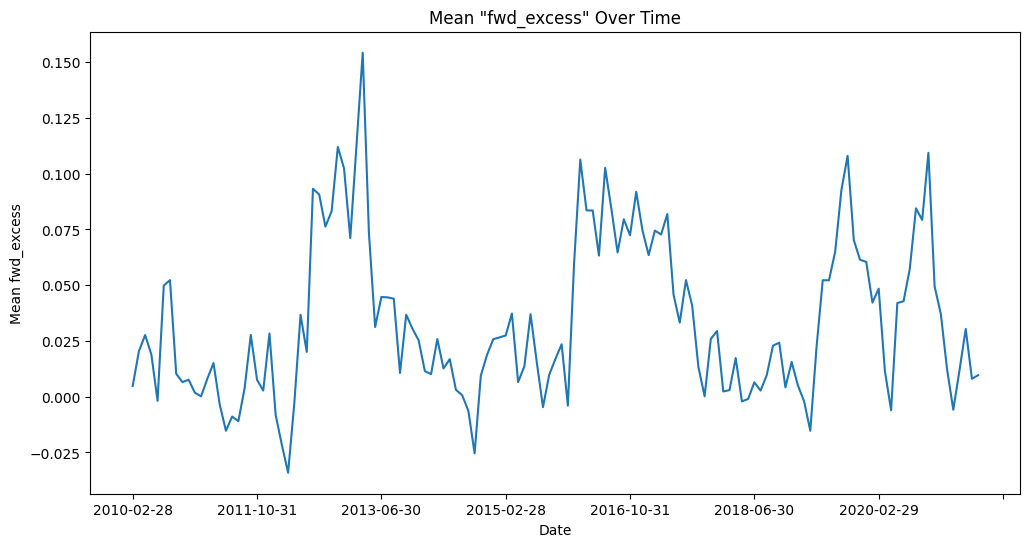

In [7]:
# Average 'fwd_excess' over time
date_group = training_data.groupby('Date')['fwd_excess'].mean()
date_group.plot(title='Mean "fwd_excess" Over Time', figsize=(12,6), ylabel='Mean fwd_excess', xlabel='Date')

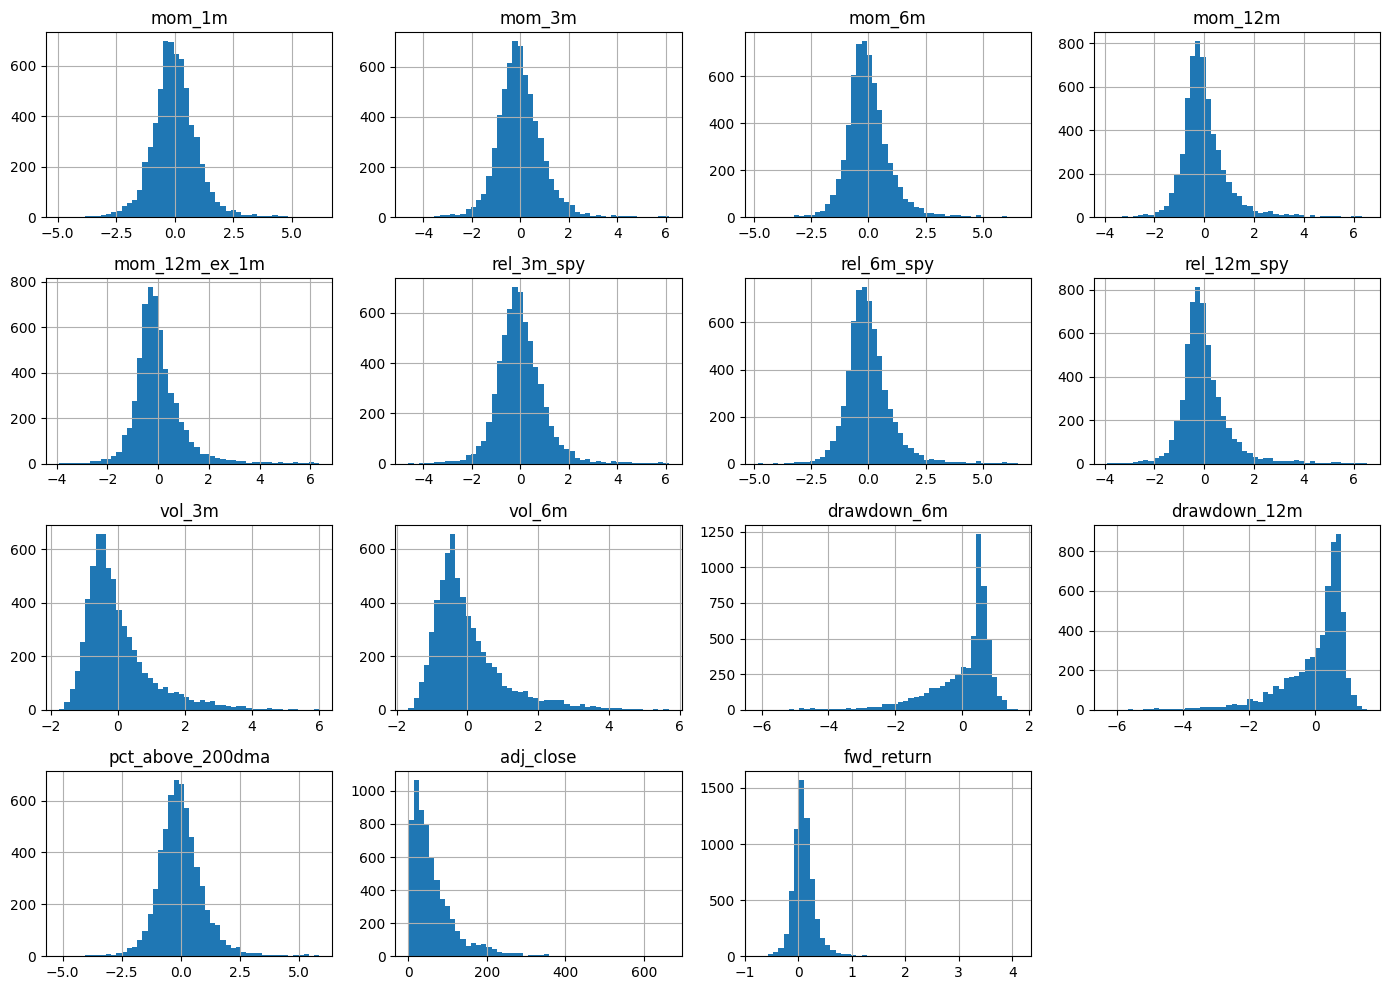

In [8]:
# Histogram of variables

cols = training_data.columns.drop(['fwd_excess','Date'])
training_data[cols].hist(figsize=(14, 10), bins=50)
plt.tight_layout()
plt.show()

Correlation of features with 'fwd_excess':
drawdown_12m       -0.061281
drawdown_6m        -0.036104
mom_1m              0.078982
mom_12m_ex_1m       0.086621
rel_12m_spy         0.105410
mom_12m             0.105410
mom_3m              0.106769
rel_3m_spy          0.106769
pct_above_200dma    0.110647
rel_6m_spy          0.117103
mom_6m              0.117103
vol_3m              0.251590
vol_6m              0.275100
fwd_return          0.948606
fwd_excess          1.000000
dtype: float64


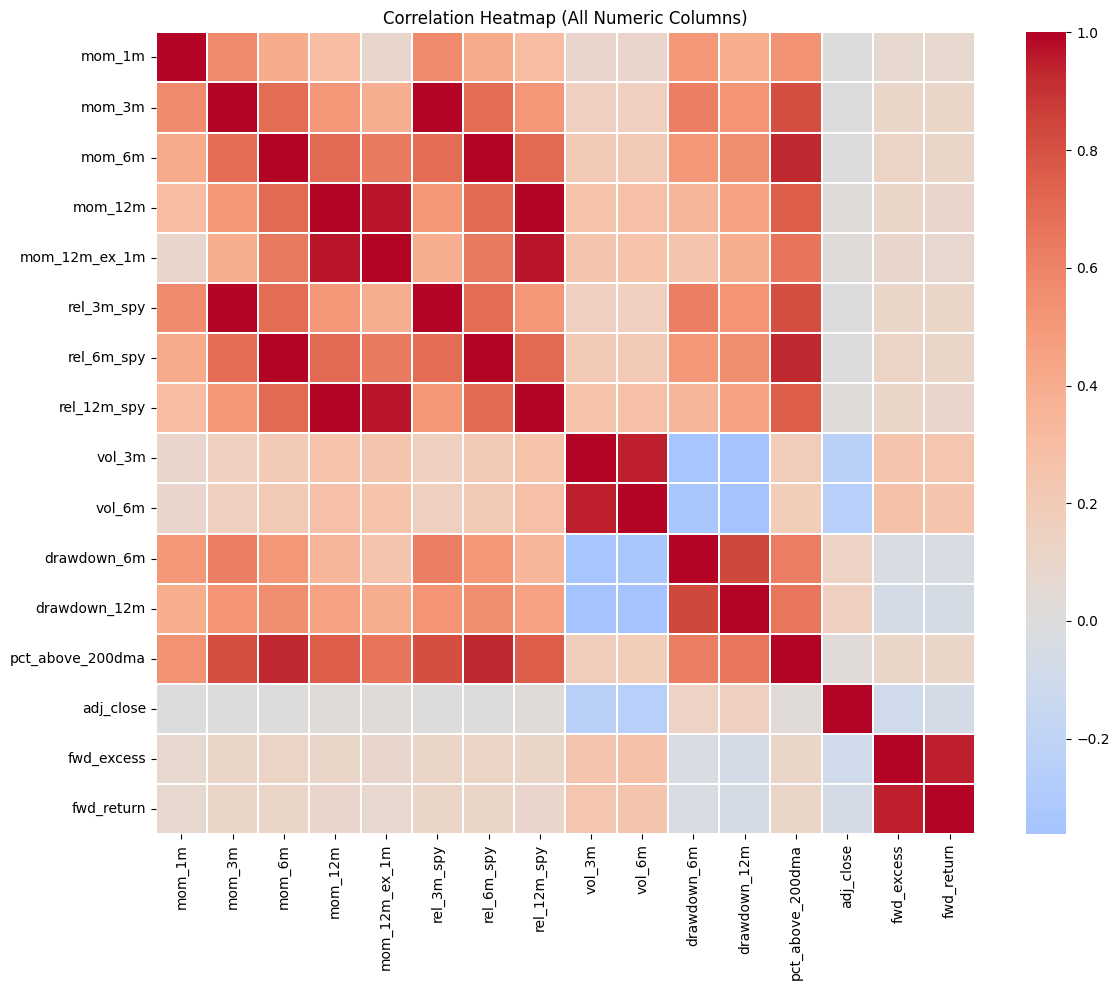

In [9]:
# Correaltion Anlaysis

# select only numeric columns for correlation
numeric_data = training_data.select_dtypes(include=[np.number])
corr = training_data.select_dtypes(include='number').corr()

fwd_excess_corr = numeric_data.corrwith(numeric_data['fwd_excess']).sort_values()
print("Correlation of features with 'fwd_excess':")
print(fwd_excess_corr.tail(15))

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.2)
plt.title('Correlation Heatmap (All Numeric Columns)')
plt.tight_layout()
plt.show()


<Axes: title={'center': 'Rolling corr: mom_12m vs fwd_excess'}, xlabel='Date', ylabel='Correlation'>

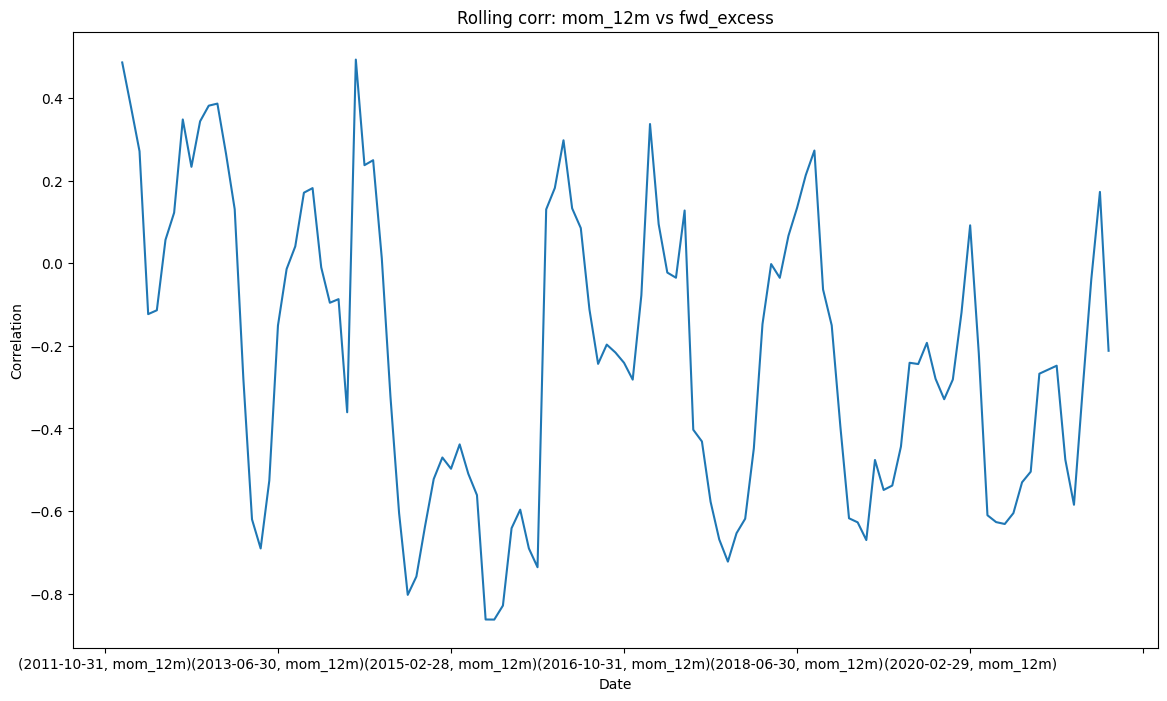

In [10]:
# Example rolling correlation by date
tmp = training_data.reset_index()
tmp = tmp.sort_values('Date')
roll = tmp.groupby('Date')[['mom_12m','fwd_excess']].mean().rolling(12).corr().iloc[0::2,1]
roll.plot(title='Rolling corr: mom_12m vs fwd_excess', figsize=(14,8), ylabel='Correlation', xlabel='Date')

<Axes: title={'center': 'Cross-sectional corr by Date'}, xlabel='Date', ylabel='Correlation'>

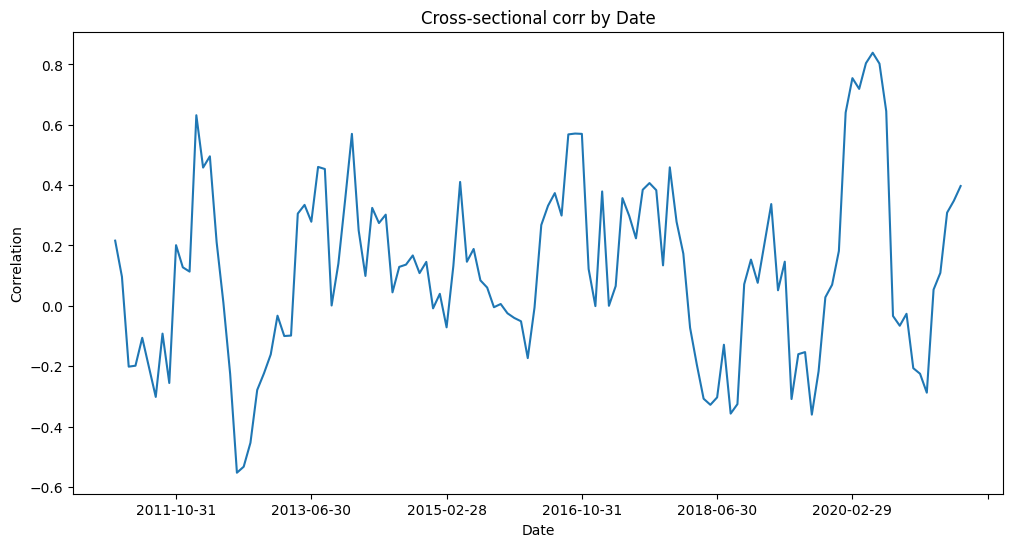

In [ ]:
''' 
Cross ‑ sectional analysis per date
For each month, examine signal effectiveness cross‑sectionally
Rank features by how well they explain fwd_excess
'''

# Cross-sectional correlation per date
cs_corr = tmp.groupby('Date').apply(lambda g: g['mom_12m'].corr(g['fwd_excess']))
cs_corr.plot(title='Cross-sectional corr by Date',figsize=(12,6), ylabel='Correlation', xlabel='Date')

In [12]:
'''
Potential Outlier influence
Extreme fwd_excess tails: which tickers/dates drive them?
Winsorization sensitivity checks
'''

q = training_data['fwd_excess'].quantile([0.01, 0.99])
tail = training_data[(training_data['fwd_excess']<=q.iloc[0]) | (training_data['fwd_excess']>=q.iloc[1])]
tail.reset_index().groupby('Ticker').size().sort_values(ascending=False).head(10)

Ticker
AMD     22
TSLA    21
NFLX    20
NVDA    13
GE      11
MU       9
BABA     7
WFC      6
BAC      4
PLTR     3
dtype: int64

In [13]:
zip_path = "HelpHerInvest/Data/stock_symbols_new.csv.zip"

with zipfile.ZipFile(zip_path) as z:
    df = pd.read_csv(z.open("stock_symbols_new.csv"))

df.head()

,symbol,company_name,address1,city,state,zip,country,phone,website,industry,...,address3,morningStarOverallRating,morningStarRiskRating,annualReportExpenseRatio,lastCapGain,annualHoldingsTurnover,prevTicker,tickerChangeDate,newListingDate,delistingDate
0,NVDA,NVIDIA CORP,2788 San Tomas Expressway,Santa Clara,CA,95051,United States,408 486 2000,https://www.nvidia.com,Semiconductors,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GOOGL,Alphabet Inc.,1600 Amphitheatre Parkway,Mountain View,CA,94043,United States,650-253-0000,https://abc.xyz,Internet Content & Information,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AAPL,Apple Inc.,One Apple Park Way,Cupertino,CA,95014,United States,(408) 996-1010,https://www.apple.com,Consumer Electronics,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MSFT,MICROSOFT CORP,One Microsoft Way,Redmond,WA,98052-6399,United States,425 882 8080,https://www.microsoft.com,Software - Infrastructure,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AMZN,AMAZON COM INC,410 Terry Avenue North,Seattle,WA,98109-5210,United States,206 266 1000,https://www.amazon.com,Internet Retail,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# Detect key NLP columns robustly

def find_col(candidates, columns):
    colmap = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in colmap:
            return colmap[cand.lower()]
    return None

sector_col = find_col(["sector", "sectorDisp", "sectorKey"], df.columns)
industry_col = find_col(["industry", "industryDisp", "industryKey"], df.columns)
summary_col = find_col(["longBusinessSummary", "businessSummary", "summary", "description"], df.columns)

symbol_col = find_col(["symbol", "ticker"], df.columns)
name_col = find_col(["company_name", "shortName", "longName", "name"], df.columns)
quote_type_col = find_col(["quoteType"], df.columns)

print("Detected columns:")
print("  symbol:", symbol_col)
print("  company:", name_col)
print("  quoteType:", quote_type_col)
print("  sector:", sector_col)
print("  industry:", industry_col)
print("  summary:", summary_col)

assert sector_col and industry_col and summary_col, "Missing required NLP columns."

Detected columns:
  symbol: symbol
  company: company_name
  quoteType: quoteType
  sector: sector
  industry: industry
  summary: longBusinessSummary


,field,rows,null_count,empty_or_whitespace_count,nonempty_count,pct_null,pct_empty_or_whitespace
0,sector,10284,1812,1812,8472,0.176196,0.176196
1,industry,10284,1812,1812,8472,0.176196,0.176196
2,longBusinessSummary,10284,1103,1103,9181,0.107254,0.107254


,quoteType,_miss_sector,_miss_industry,_miss_summary
0,ECNQUOTE,1.000000,1.000000,1.000000
1,ETF,1.000000,1.000000,0.241206
2,MUTUALFUND,1.000000,1.000000,0.990566
3,NONE,1.000000,1.000000,1.000000
4,EQUITY,0.114178,0.114178,0.055939


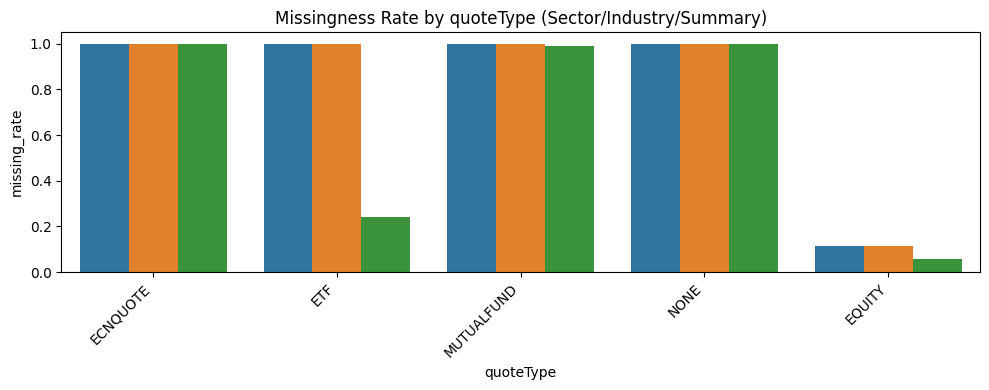

In [15]:
#  Coverage / missingness (overall + by quoteType)

def missing_report(s: pd.Series, name: str):
    s2 = s.copy()
    null_count = int(s2.isna().sum())
    empty_count = int((s2.fillna("").astype(str).str.strip() == "").sum())
    n = len(s2)
    return {
        "field": name,
        "rows": n,
        "null_count": null_count,
        "empty_or_whitespace_count": empty_count,
        "nonempty_count": n - empty_count,
        "pct_null": null_count / n,
        "pct_empty_or_whitespace": empty_count / n,
    }

coverage = pd.DataFrame([
    missing_report(df[sector_col], sector_col),
    missing_report(df[industry_col], industry_col),
    missing_report(df[summary_col], summary_col),
])

display(coverage)


if quote_type_col:
    def is_missing_text(series):
        return series.isna() | (series.astype(str).str.strip() == "")

    tmp = df.copy()
    tmp["_miss_sector"] = is_missing_text(tmp[sector_col])
    tmp["_miss_industry"] = is_missing_text(tmp[industry_col])
    tmp["_miss_summary"] = is_missing_text(tmp[summary_col])

    by_qt = (tmp.groupby(quote_type_col)[["_miss_sector","_miss_industry","_miss_summary"]]
             .mean()
             .sort_values("_miss_sector", ascending=False)
             .reset_index())

    display(by_qt)


    plt.figure(figsize=(10,4))
    melted = by_qt.melt(id_vars=quote_type_col, var_name="field", value_name="missing_rate")
    sns.barplot(data=melted, x=quote_type_col, y="missing_rate", hue="field")
    plt.xticks(rotation=45, ha="right")
    plt.title("Missingness Rate by quoteType (Sector/Industry/Summary)")
    plt.tight_layout()
    plt.show()

Unique sectors: 11
Unique industries: 145


,sector,count
0,Financial Services,2014
1,NaN,1812
2,Healthcare,1418
3,Technology,1000
4,Industrials,939
5,Consumer Cyclical,711
6,Basic Materials,607
7,Real Estate,448
8,Communication Services,401
9,Consumer Defensive,381


,industry,count
0,NaN,1812
1,Biotechnology,721
2,Asset Management,569
3,Banks - Regional,484
4,Shell Companies,450
5,Software - Application,320
6,Software - Infrastructure,197
7,Medical Devices,182
8,Other Industrial Metals & Mining,175
9,Drug Manufacturers - Specialty & Generic,163


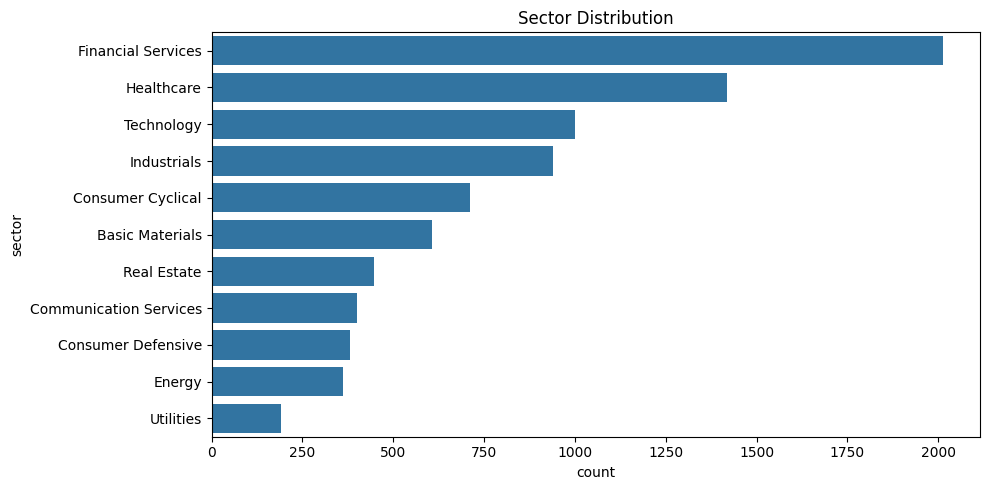

,industry,n_sectors_for_industry
0,Advertising Agencies,1
1,Aerospace & Defense,1
2,Agricultural Inputs,1
3,Airlines,1
4,Airports & Air Services,1
5,Aluminum,1
6,Apparel Manufacturing,1
7,Apparel Retail,1
8,Asset Management,1
9,Auto & Truck Dealerships,1


In [16]:
# Sector/industry distributions + cross-checks

sector_counts = df[sector_col].value_counts(dropna=False).reset_index()
sector_counts.columns = ["sector", "count"]
industry_counts = df[industry_col].value_counts(dropna=False).reset_index()
industry_counts.columns = ["industry", "count"]

print("Unique sectors:", df[sector_col].nunique(dropna=True))
print("Unique industries:", df[industry_col].nunique(dropna=True))

display(sector_counts.head(20))
display(industry_counts.head(20))

# Plot sector distribution
plt.figure(figsize=(10,5))
top_sector = sector_counts.dropna().head(20)
sns.barplot(data=top_sector, x="count", y="sector")
plt.title("Sector Distribution")
plt.tight_layout()
plt.show()

# Industries appearing in multiple sectors (potential label issues)
inds_multi_sector = (df.dropna(subset=[sector_col, industry_col])
                       .groupby(industry_col)[sector_col]
                       .nunique()
                       .sort_values(ascending=False)
                       .reset_index()
                       .rename(columns={sector_col:"n_sectors_for_industry"}))

display(inds_multi_sector.head(30))

,metric,count,mean,median,p95,p99,max
0,char_len,9181,966.489271,864.0,1944.0,1998.0,5342
1,word_len,9181,133.112624,122.0,254.0,277.0,746
2,sent_len,9181,8.585775,8.0,14.0,18.0,38


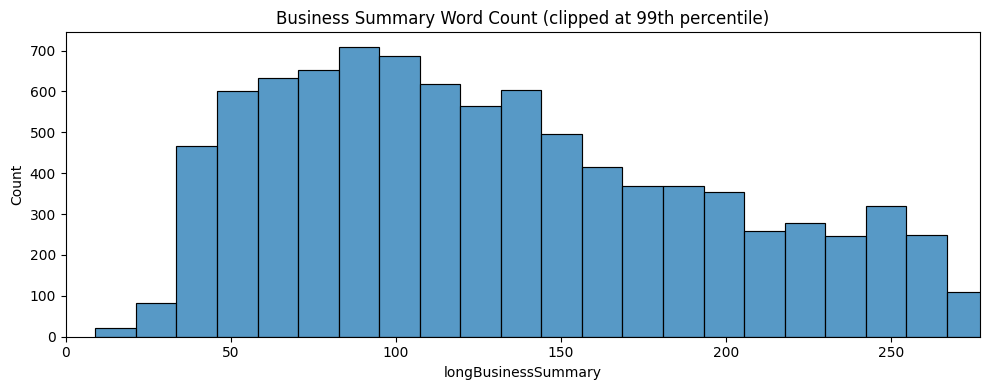

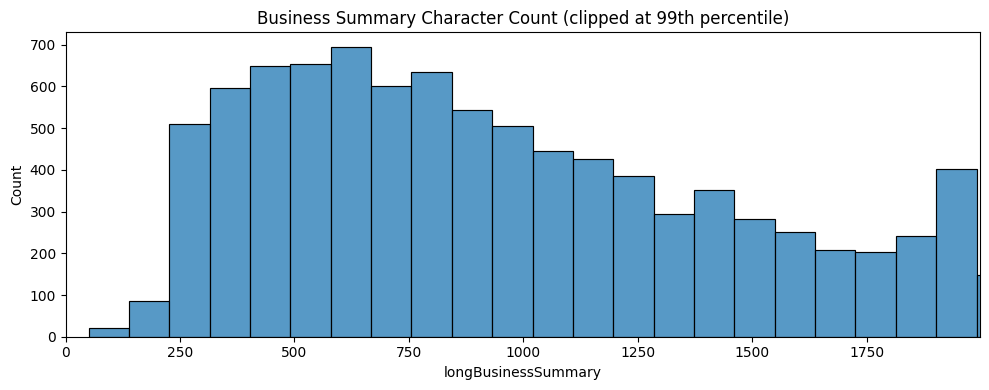

,symbol,company_name,quoteType,sector,industry,longBusinessSummary
3022,MEGI,NYLI CBRE Global Infrastructure Megatrends Ter...,EQUITY,Financial Services,Asset Management,NYLI CBRE Global Infrastructure Megatrends Ter...
3669,XFLT,XAI Octagon Floating Rate & Alternative Income...,EQUITY,Financial Services,Asset Management,XAI Octagon Floating Rate & Alternative Income...
4544,OCCI,"OFS Credit Company, Inc.",EQUITY,Financial Services,Asset Management,"OFS Credit Company, Inc. is a fund of OFS Advi..."
9043,BPYPM,Brookfield Property Partners L.P.,EQUITY,Financial Services,Asset Management,Brookfield Property Preferred L.P. is headquar...
9230,OCCIM,"OFS Credit Company, Inc.",EQUITY,Financial Services,Asset Management,"OFS Credit Company, Inc. is a fund of OFS Advi..."
9231,OCCIN,"OFS Credit Company, Inc.",EQUITY,Financial Services,Asset Management,"OFS Credit Company, Inc. is a fund of OFS Advi..."
9232,OCCIO,"OFS Credit Company, Inc.",EQUITY,Financial Services,Asset Management,"OFS Credit Company, Inc. is a fund of OFS Advi..."


In [17]:
# Business summary length profiling (plots + outliers) 

summ = df[summary_col].fillna("").astype(str).str.strip()
nonempty = summ[summ != ""]

char_len = nonempty.str.len()
word_len = nonempty.str.split().str.len()
sent_len = nonempty.str.count(r"[.!?]") + 1

length_stats = pd.DataFrame({
    "metric": ["char_len","word_len","sent_len"],
    "count": [len(char_len), len(word_len), len(sent_len)],
    "mean": [char_len.mean(), word_len.mean(), sent_len.mean()],
    "median": [char_len.median(), word_len.median(), sent_len.median()],
    "p95": [char_len.quantile(0.95), word_len.quantile(0.95), sent_len.quantile(0.95)],
    "p99": [char_len.quantile(0.99), word_len.quantile(0.99), sent_len.quantile(0.99)],
    "max": [char_len.max(), word_len.max(), sent_len.max()],
})

display(length_stats)

# Histograms
plt.figure(figsize=(10,4))
sns.histplot(word_len, bins=60)
plt.xlim(0, np.percentile(word_len, 99))
plt.title("Business Summary Word Count (clipped at 99th percentile)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
sns.histplot(char_len, bins=60)
plt.xlim(0, np.percentile(char_len, 99))
plt.title("Business Summary Character Count (clipped at 99th percentile)")
plt.tight_layout()
plt.show()

# Very short summaries for inspection
very_short_idx = nonempty.index[word_len < 15]
short_examples = df.loc[very_short_idx, [c for c in [symbol_col, name_col, quote_type_col, sector_col, industry_col, summary_col] if c]].head(20)
display(short_examples)

,phrase,count,pct_of_nonempty
0,headquartered in,5341,0.581745
6,provides,4520,0.492321
1,was founded in,3866,0.421087
2,incorporated in,3768,0.410413
4,engages in,2229,0.242784
3,together with its subsidiaries,1196,0.130269
5,operates in,806,0.087790


,term,count
0,company,20212
1,services,13808
2,products,9931
3,provides,7837
4,offers,7202
5,operates,6089
6,headquartered,5342
7,united,5208
8,solutions,5138
9,management,5011


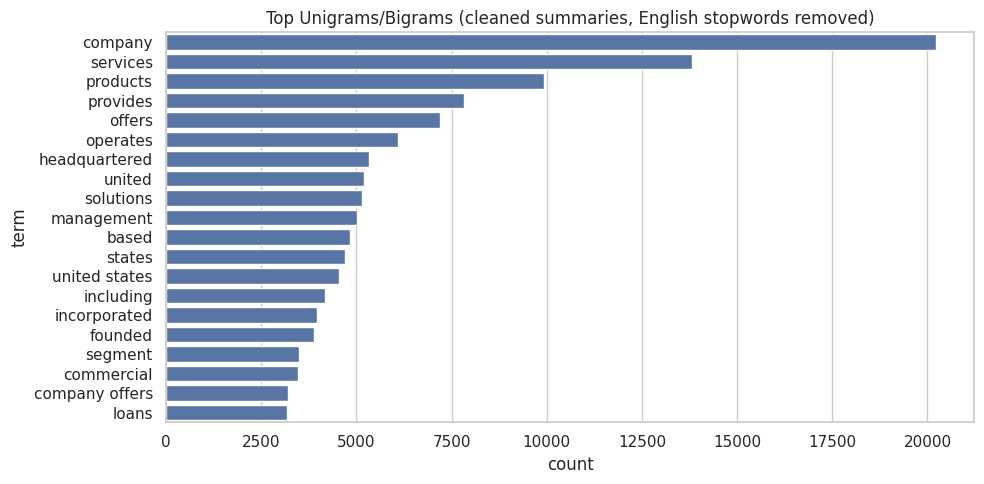

In [20]:
# Boilerplate phrase checks + top terms/ngrams 

def basic_clean(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

clean_texts = nonempty.map(basic_clean)
summ_lower = nonempty.str.lower()

common_phrases = [
    "headquartered in",
    "was founded in",
    "incorporated in",
    "together with its subsidiaries",
    "engages in",
    "operates in",
    "provides",
]

phrase_freq = pd.DataFrame({
    "phrase": common_phrases,
    "count": [int(summ_lower.str.contains(p).sum()) for p in common_phrases],
})
phrase_freq["pct_of_nonempty"] = phrase_freq["count"] / len(nonempty)
display(phrase_freq.sort_values("count", ascending=False))

# Top unigrams/bigrams
vec = CountVectorizer(stop_words="english", max_features=60, ngram_range=(1,2))
X = vec.fit_transform(clean_texts)
terms = np.array(vec.get_feature_names_out())
freq = np.asarray(X.sum(axis=0)).ravel()

top_idx = freq.argsort()[::-1][:30]
top_terms = pd.DataFrame({"term": terms[top_idx], "count": freq[top_idx]})
display(top_terms)

plt.figure(figsize=(10,5))
sns.barplot(data=top_terms.head(20), x="count", y="term")
plt.title("Top Unigrams/Bigrams (cleaned summaries, English stopwords removed)")
plt.tight_layout()
plt.show()

In [ ]:
# Exact duplicates
summary_stripped = df[summary_col].fillna("").astype(str).str.strip()
nonempty_mask = summary_stripped != ""

dup_counts = summary_stripped[nonempty_mask].value_counts()
dup_summary_stats = pd.DataFrame([{
    "distinct_nonempty_summaries": int(dup_counts.shape[0]),
    "distinct_duplicated_summaries": int((dup_counts > 1).sum()),
    "rows_in_duplicated_summaries": int(summary_stripped[nonempty_mask].map(dup_counts).gt(1).sum()),
    "max_repetition_single_summary": int(dup_counts.max())
}])

display(dup_summary_stats)

top_dup = dup_counts.head(10).reset_index()
top_dup.columns = ["summary_text", "count"]
top_dup["preview"] = top_dup["summary_text"].str.slice(0, 160) + "..."
display(top_dup[["count","preview"]])

# Near-duplicates with TF-IDF + NearestNeighbors
SAMPLE_N = None 
rng = np.random.default_rng(42)

idx = summary_stripped[nonempty_mask].index.to_numpy()
if SAMPLE_N is not None and SAMPLE_N < len(idx):
    idx = rng.choice(idx, size=SAMPLE_N, replace=False)

texts = df.loc[idx, summary_col].fillna("").astype(str).map(basic_clean)

tfidf = TfidfVectorizer(stop_words="english", min_df=3, max_df=0.90, ngram_range=(1,2))
X = tfidf.fit_transform(texts)

nn = NearestNeighbors(n_neighbors=6, metric="cosine")
nn.fit(X)
dist, neigh = nn.kneighbors(X)

SIM_THRESHOLD = 0.90
pairs = []
for row_i in range(neigh.shape[0]):
    i = idx[row_i]
    for k in range(1, neigh.shape[1]):
        j = idx[neigh[row_i, k]]
        sim = 1 - dist[row_i, k]
        if sim >= SIM_THRESHOLD:
            pairs.append((i, j, sim))

near_dup_df = (pd.DataFrame(pairs, columns=["row_i","row_j","tfidf_cosine_sim"])
               .sort_values("tfidf_cosine_sim", ascending=False))

display(near_dup_df.head(30))

# add metadata for top pairs
cols_to_show = [c for c in [symbol_col, name_col, quote_type_col, sector_col, industry_col, summary_col] if c]
if len(near_dup_df) > 0 and cols_to_show:
    sample_pairs = near_dup_df.head(20).copy()
    left = df.loc[sample_pairs["row_i"], cols_to_show].reset_index().rename(columns={"index":"row_i"})
    right = df.loc[sample_pairs["row_j"], cols_to_show].reset_index().rename(columns={"index":"row_j"})
    show = sample_pairs.merge(left, on="row_i").merge(right, on="row_j", suffixes=("_A","_B"))
    display(show.head(10))

,distinct_nonempty_summaries,distinct_duplicated_summaries,rows_in_duplicated_summaries,max_repetition_single_summary
0,7628,1044,2597,22


,count,preview
0,22,"Federal Home Loan Mortgage Corporation operates in the secondary mortgage market in the United States. It operates through two segments, Single-Family and Multi..."
1,16,Federal National Mortgage Association provides financing solutions for residential mortgages in the United States. The company operates through Single-Family an...
2,15,"Public Storage, a member of the S&P 500, is a REIT that primarily acquires, develops, owns, and operates self-storage facilities. At September 30, 2025, we: (i)..."
3,15,"Bank of America Corporation, through its subsidiaries, provides various financial products and services for individual consumers, small and middle-market busine..."
4,13,"The Connecticut Light and Power Company, a regulated electric utility, engages in the purchase, delivery, and sale of electricity to residential, commercial, an..."
5,11,"Enbridge Inc., together with its subsidiaries, operates as an energy infrastructure company. The company operates through four segments: Liquids Pipelines, Gas ..."
6,10,"Morgan Stanley, a financial holding company, provides various financial products and services to governments, financial institutions, and individuals in the Ame..."
7,8,"Union Electric Company, doing business as Ameren Missouri, engages in the rate-regulated electric generation, transmission, and distribution business in Missour..."
8,7,"Adamas Trust, Inc. acquires, invests in, finances, and manages mortgage-related single-family and multi-family residential assets in the United States. The comp..."
9,7,Federal Agricultural Mortgage Corporation provides a secondary market for various loans made to borrowers in the United States. It operates through seven segmen...


In [ ]:
def safe_str(x):
    if pd.isna(x):
        return ""
    return str(x).strip()

def build_embed_text(row):
    parts = []
    if safe_str(row[sector_col]):
        parts.append(f"Sector: {safe_str(row[sector_col])}")
    if safe_str(row[industry_col]):
        parts.append(f"Industry: {safe_str(row[industry_col])}")
    if safe_str(row[summary_col]):
        parts.append(f"Summary: {safe_str(row[summary_col])}")
    return " | ".join(parts).strip()

df["embed_text"] = df.apply(build_embed_text, axis=1)
df["embed_text_is_empty"] = df["embed_text"].str.strip().eq("")

embed_ready_stats = pd.DataFrame([{
    "rows_total": len(df),
    "rows_embed_text_empty": int(df["embed_text_is_empty"].sum()),
    "rows_embed_text_nonempty": int((~df["embed_text_is_empty"]).sum())
}])

display(embed_ready_stats)

In [ ]:
def can_push():
    result = subprocess.run(
        ["git", "-C", REPO_DIR, "push", "--dry-run"],
        capture_output=True, text=True
    )
    return result.returncode == 0

def commit_and_push(msg="update"):
    subprocess.run(["git", "-C", REPO_DIR, "add", "-A"])
    subprocess.run(["git", "-C", REPO_DIR, "commit", "-m", msg])
    subprocess.run(["git", "-C", REPO_DIR, "push"])

if can_push():
    commit_and_push("update notebook / data")
else:
    print("Not a collaborator — skipping push")